PART D - Imbalance & Operational Stress
(imbalance = arrivals - departures )

For Part D, I load the trip data, count how many arrivals and departures each station has, and compute the imbalance using the formula:

imbalance = arrivals − departures.

Then I list the stations that keep emptying, the stations that keep overfilling, and the ones that change the most day-to-day.

I added more analysis by looking at time-of-day patterns and grouped the data into four slices (AM, Mid, PM, Night) to see when stations are most stressed. This shows patterns like stations emptying during the morning commute or filling up heavily at night.

I also calculated a daily imbalance for every station and used it to measure two important things:

the magnitude of the imbalance on average

the volatility across days

Using both of these, I created a truck priority score to highlight the stations that need the most rebalancing attention. High-score stations are the ones that consistently shift a lot or swing sharply day to day.

At the end, I generated a heatmap of imbalance across time slices, which helps visualize which stations have problems and when those problems occur. This makes it easier to see patterns that the overall totals might hide.


/var/folders/lt/0y1_b0353bn8xc4j6_sc_chr0000gn/T/ipykernel_15664/1978211554.py:15: DtypeWarning: Columns (5,7) have mixed types. Specify dtype option on import or set low_memory=False.
  dfs.append(pd.read_csv(f))
/var/folders/lt/0y1_b0353bn8xc4j6_sc_chr0000gn/T/ipykernel_15664/1978211554.py:15: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  dfs.append(pd.read_csv(f))
/var/folders/lt/0y1_b0353bn8xc4j6_sc_chr0000gn/T/ipykernel_15664/1978211554.py:15: DtypeWarning: Columns (5,7) have mixed types. Specify dtype option on import or set low_memory=False.
  dfs.append(pd.read_csv(f))
/var/folders/lt/0y1_b0353bn8xc4j6_sc_chr0000gn/T/ipykernel_15664/1978211554.py:15: DtypeWarning: Columns (5,7) have mixed types. Specify dtype option on import or set low_memory=False.
  dfs.append(pd.read_csv(f))


=== Stations That Keep Emptying (Deficits) ===
                            arrivals  departures  imbalance
Broadway & E 14 St              7397     11630.0    -4233.0
6 Ave & W 33 St                 6497     10365.0    -3868.0
Pier 61 at Chelsea Piers        9806     13436.0    -3630.0
7 Ave & Central Park South      5065      8102.0    -3037.0
11 Ave & W 27 St                3304      6334.0    -3030.0
W 54 St & 11 Ave                4052      6780.0    -2728.0
West St & Liberty St            4257      6813.0    -2556.0
1 Ave & E 68 St                 7589     10054.0    -2465.0
E 32 St & Park Ave              4938      7342.0    -2404.0
W 70 St & Amsterdam Ave         4181      6378.0    -2197.0
E 55 St & 2 Ave                 2393      4513.0    -2120.0
E 74 St & 1 Ave                 3442      5547.0    -2105.0
Broadway & W 61 St              3522      5621.0    -2099.0
W 67 St & Broadway              4206      6294.0    -2088.0
W 59 St & 10 Ave                3239      5291.0    -

,start_station_name,time_slice,end_station_name,departures,arrivals,imbalance
0,1 Ave & E 110 St,AM,1 Ave & E 110 St,607,389,-218
1,1 Ave & E 110 St,AM,1 Ave & E 118 St,607,393,-214
2,1 Ave & E 110 St,AM,1 Ave & E 16 St,607,1566,959
3,1 Ave & E 110 St,AM,1 Ave & E 18 St,607,843,236
4,1 Ave & E 110 St,AM,1 Ave & E 30 St,607,2691,2084


Top 15 high-stress stations:


,magnitude,volatility,truck_priority_score
station,,,
West St & Chambers St,70.406977,142.149414,99.103952
University Pl & E 14 St,50.689655,110.779092,74.725430
11 Ave & W 41 St,53.011905,102.481911,72.799907
Central Park S & 6 Ave,52.674699,96.573630,70.234271
Broadway & E 21 St,48.602273,92.827555,66.292386
Pier 61 at Chelsea Piers,41.724138,98.406926,64.397253
W 41 St & 8 Ave,12.566265,132.722633,60.628812
West End Ave & W 60 St,45.011765,80.557949,59.230239
Broadway & E 14 St,48.655172,74.195033,58.871117


Combined arrival + departure volatility:


,arrival_vol,departure_vol,combined_volatility
station,,,
1 Ave & E 110 St,21.990425,18.735225,20.362825
1 Ave & E 118 St,11.907719,12.920781,12.414250
1 Ave & E 16 St,75.368388,49.920466,62.644427
1 Ave & E 18 St,70.697944,56.725468,63.711706
1 Ave & E 30 St,69.391197,60.790546,65.090872


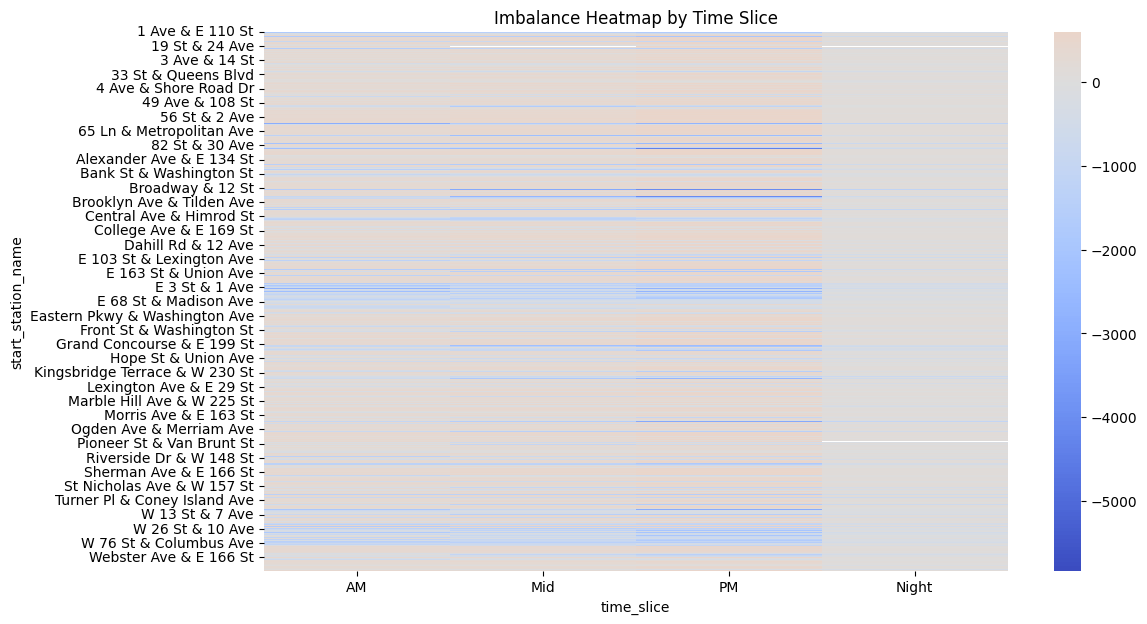

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

files = [
    "202501-citibike-tripdata_1.csv",
    "202502-citibike-tripdata_1.csv",
    "202503-citibike-tripdata_1.csv",
    "202504-citibike-tripdata_4.csv"
]

dfs = []
for f in files:
    dfs.append(pd.read_csv(f))

df = pd.concat(dfs, ignore_index=True)

df["started_at"] = pd.to_datetime(df["started_at"])
df["ended_at"] = pd.to_datetime(df["ended_at"])

departures = df.groupby("start_station_name").size().rename("departures")
arrivals = df.groupby("end_station_name").size().rename("arrivals")

imbalance = pd.concat([arrivals, departures], axis=1).fillna(0)
imbalance["imbalance"] = imbalance["arrivals"] - imbalance["departures"]

top_deficits = imbalance.sort_values("imbalance").head(15)
top_surplus = imbalance.sort_values("imbalance", ascending=False).head(15)

df["date"] = df["started_at"].dt.date
daily_counts = df.groupby(["date", "start_station_name"]).size().unstack(fill_value=0)
volatility = daily_counts.std().sort_values(ascending=False)

print("=== Stations That Keep Emptying (Deficits) ===")
print(top_deficits)
print("\n=== Stations That Keep Overfilling (Surplus) ===")
print(top_surplus)
print("\n=== Most Volatile Stations (Day-to-Day Changes) ===")
print(volatility.head(15))

df["is_weekend"] = df["started_at"].dt.weekday >= 5

def time_slice(hour):
    if 5 <= hour < 11:
        return "AM"
    elif 11 <= hour < 16:
        return "Mid"
    elif 16 <= hour < 21:
        return "PM"
    else:
        return "Night"

df["time_slice"] = df["started_at"].dt.hour.apply(time_slice)

slice_imbalance = (
    df.groupby(["start_station_name", "time_slice"]).size().rename("departures")
      .to_frame()
      .join(df.groupby(["end_station_name", "time_slice"]).size().rename("arrivals"))
      .fillna(0)
)

slice_imbalance["imbalance"] = slice_imbalance["arrivals"] - slice_imbalance["departures"]
slice_imbalance = slice_imbalance.reset_index()

print("Time-slice imbalance sample:")
display(slice_imbalance.head())

daily_dep = (
    df.groupby([df["started_at"].dt.date, "start_station_name"])
      .size()
      .rename("departures")
)

daily_arr = (
    df.groupby([df["ended_at"].dt.date, "end_station_name"])
      .size()
      .rename("arrivals")
)

daily_dep.index = daily_dep.index.set_names(["date", "station"])
daily_arr.index = daily_arr.index.set_names(["date", "station"])

daily = pd.concat([daily_dep, daily_arr], axis=1).fillna(0)
daily["imbalance"] = daily["arrivals"] - daily["departures"]

mag = daily.groupby("station")["imbalance"].mean().abs().rename("magnitude")
vol = daily.groupby("station")["imbalance"].std().rename("volatility")

priority = pd.concat([mag, vol], axis=1).fillna(0)
priority["truck_priority_score"] = 0.6 * priority["magnitude"] + 0.4 * priority["volatility"]
priority = priority.sort_values("truck_priority_score", ascending=False)

print("Top 15 high-stress stations:")
display(priority.head(15))

daily2 = pd.DataFrame()
daily2["arrivals"] = df.groupby([df["ended_at"].dt.date, "end_station_name"]).size()
daily2["departures"] = df.groupby([df["started_at"].dt.date, "start_station_name"]).size()
daily2 = daily2.fillna(0)

daily2.index = daily2.index.set_names(["date", "station"])

vol_arr = daily2.groupby("station")["arrivals"].std().rename("arrival_vol")
vol_dep = daily2.groupby("station")["departures"].std().rename("departure_vol")

vol_combo = pd.concat([vol_arr, vol_dep], axis=1).fillna(0)
vol_combo["combined_volatility"] = vol_combo.mean(axis=1)

print("Combined arrival + departure volatility:")
display(vol_combo.head())

pivot = slice_imbalance.pivot_table(
    index="start_station_name",
    columns="time_slice",
    values="imbalance",
    aggfunc="mean"
).reindex(columns=["AM", "Mid", "PM", "Night"])

plt.figure(figsize=(12, 7))
sns.heatmap(pivot, cmap="coolwarm", center=0)
plt.title("Imbalance Heatmap by Time Slice")
plt.show()


PART F — Network Inference & Link Prediction

For Part F, I build a station network from the trip data and then run three link-prediction methods: Adamic–Adar, Preferential Attachment, and Common Neighbors. These scores help me find “emerging” connections between stations, meaning station pairs that might grow into strong corridors in the future even if they don’t currently have many trips.

To evaluate these methods in a more realistic way, I divide the dataset into a training period (January-March) and a testing period (April). I construct a weighted network from the training data and a separate network from the April data, and then identify the set of emerging edges-station pairs that appear in April but were not present during the earlier months. These emerging edges serve as the ground-truth future connections that the link-prediction methods aim to forecast.

After computing the three predictor scores for all candidate pairs, I merge the results into a single table and apply a geographic distance filter. Using each station’s latitude and longitude, I keep only pairs that lie within approximately 2 kilometers of each other. This makes the predictions more operationally meaningful by removing unrealistic long-distance connections.

Next, I create a final combined score for each station pair by summing the three predictors. I then rank all candidate pairs by this score and examine the top 100 predicted links. To measure how well the methods perform, I compute Precision@100, which reports how many of these top predicted links actually became emerging edges in April. This gives a clear, quantitative way to see how effective the link-prediction approach is for forecasting future Citi Bike demand patterns.

In [8]:
import pandas as pd
import networkx as nx
import numpy as np

df["month"] = df["started_at"].dt.month

train = df[df["month"].isin([1, 2, 3])]
test = df[df["month"] == 4]

print("Training rows:", len(train))
print("Test rows:", len(test))

def build_graph(data):
    G = nx.Graph()
    grouped = data.groupby(["start_station_name", "end_station_name"]).size()
    for (u, v), w in grouped.items():
        if u != v:
            if G.has_edge(u, v):
                G[u][v]["weight"] += w
            else:
                G.add_edge(u, v, weight=w)
    return G

G_train = build_graph(train)
G_test = build_graph(test)

train_edges = set(G_train.edges())
test_edges = set(G_test.edges())
emerging_edges = list(test_edges - train_edges)

print("Emerging edges:", len(emerging_edges))

aa = list(nx.adamic_adar_index(G_train))
aa_df = pd.DataFrame([(u, v, s) for u, v, s in aa],
                     columns=["u", "v", "aa_score"])

pa = list(nx.preferential_attachment(G_train))
pa_df = pd.DataFrame([(u, v, s) for u, v, s in pa],
                     columns=["u", "v", "pa_score"])

cn_rows = []
for u, v in G_train.edges():
    cn_rows.append((u, v, len(list(nx.common_neighbors(G_train, u, v)))))

cn_df = pd.DataFrame(cn_rows, columns=["u", "v", "cn_score"])

pred = aa_df.merge(pa_df, on=["u", "v"], how="outer").merge(cn_df, on=["u", "v"], how="outer")
pred = pred.fillna(0)

print("Prediction candidate pairs:", len(pred))

coords = df.groupby("start_station_name")[["start_lat", "start_lng"]].mean()

def close(u, v, max_km=2):
    if u not in coords.index or v not in coords.index:
        return False
    x1, y1 = coords.loc[u]
    x2, y2 = coords.loc[v]
    d = np.sqrt((x1 - x2)**2 + (y1 - y2)**2) * 111
    return d <= max_km

pred["is_close"] = pred.apply(lambda r: close(r.u, r.v), axis=1)
pred = pred[pred["is_close"]]

print("Filtered candidates:", len(pred))

pred["final_score"] = pred["aa_score"] + pred["pa_score"] + pred["cn_score"]
pred_sorted = pred.sort_values("final_score", ascending=False)

K = 100
topK = pred_sorted.head(K)
topK_pairs = set((row.u, row.v) for _, row in topK.iterrows())

hits = len(topK_pairs & set(emerging_edges))
precision_at_k = hits / K

print("Precision@100:", precision_at_k)
print("Hits:", hits, "of", K)
display(topK)


Training rows: 2999793
Test rows: 724596
Emerging edges: 96512
Prediction candidate pairs: 2414503
Filtered candidates: 94336
Precision@100: 0.16
Hits: 16 of 100


,u,v,aa_score,pa_score,cn_score,is_close,final_score
1941796,Rivington St & Ridge St,Front St & Washington St,60.938129,367380.0,0.0,True,367440.938129
1961272,S 2 St & Kent Ave,E 7 St & Ave B,55.762863,359286.0,0.0,True,359341.762863
1355767,Franklin St & Dupont St,1 Ave & E 38 St,47.684757,355914.0,0.0,True,355961.684757
1830889,Park Ave & E 41 St,3 Ave & E 62 St,60.181124,346902.0,0.0,True,346962.181124
1232835,E 6 St & Ave B,Forsyth St & Canal St,67.490857,342300.0,0.0,True,342367.490857
...,...,...,...,...,...,...,...
1536298,Jay St & York St,Catherine St & Monroe St,44.398524,246257.0,0.0,True,246301.398524
2020677,South St & Gouverneur Ln,Clinton St & Tillary St,44.924682,245534.0,0.0,True,245578.924682
1184442,E 33 St & 1 Ave,Center Blvd & 51 Ave,31.320247,244622.0,0.0,True,244653.320247
716429,Broadway & Berry St,Stanton St & Mangin St,41.293063,244440.0,0.0,True,244481.293063
